In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go


df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [5]:
uva = df[df["Institution Name"] == "University of Virginia"].copy()

print(f"Total foreign gifts: {uva['Foreign Gift Amount'].sum()}")
print(f"Number of gifts: {len(uva)}")
print(f"Average gift: {uva['Foreign Gift Amount'].mean()}")
print(f"Median gift: {uva['Foreign Gift Amount'].median()}")

Total foreign gifts: 22189238
Number of gifts: 98
Average gift: 226420.79591836734
Median gift: 80535.5


In [17]:
uva_country = uva.groupby("Country of Giftor")["Foreign Gift Amount"].agg(["sum", "count", "mean", "median"]).sort_values("sum", ascending=False)

uva_country

,sum,count,mean,median
Country of Giftor,,,,
BANGLADESH,4228589,10,422858.900000,307225.5
SWEDEN,4007552,10,400755.200000,133055.0
TANZANIA,2776447,3,925482.333333,1035339.0
SWITZERLAND,2000000,2,1000000.000000,1000000.0
ENGLAND,1950666,31,62924.709677,20982.0
GUERNSEY,1500000,3,500000.000000,500000.0
FINLAND,1008384,7,144054.857143,84376.0
BERMUDA,900000,1,900000.000000,900000.0
KOREA,862787,6,143797.833333,122467.0


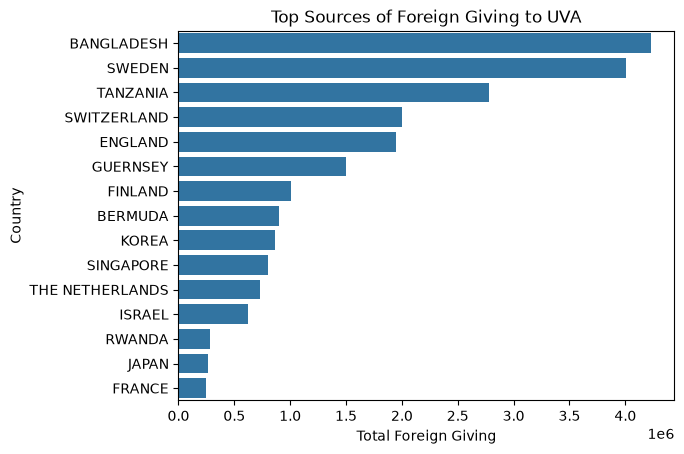

In [21]:
sns.barplot(data = uva_country, x = "sum", y = uva_country.index)
plt.xlabel("Total Foreign Giving")
plt.ylabel("Country")
plt.title("Top Sources of Foreign Giving to UVA")
plt.show()

In [26]:
total_by_country = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(15).reset_index()
total_by_country

,Country of Giftor,Foreign Gift Amount
0,QATAR,2706240869
1,ENGLAND,1464906771
2,CHINA,1237952112
3,SAUDI ARABIA,1065205930
4,BERMUDA,899593972
5,CANADA,898160656
6,HONG KONG,887402529
7,JAPAN,655954776
8,SWITZERLAND,619899445
9,INDIA,539556490


In [63]:
uva_country_count = uva.groupby("Country of Giftor").size().sort_values(ascending=False).reset_index(name = 'count')
uva_country_count.head(10)

,Country of Giftor,count
0,ENGLAND,31
1,ISRAEL,12
2,BANGLADESH,10
3,SWEDEN,10
4,FINLAND,7
5,KOREA,6
6,FRANCE,5
7,THE NETHERLANDS,4
8,GUERNSEY,3
9,TANZANIA,3


In [68]:
uva_country_summary = (uva.groupby("Country of Giftor")["Foreign Gift Amount"].agg(total_giving="sum",
                                                                                   number_of_gifts="count",
                                                                                   average_gift="mean",
                                                                                   median_gift="median").sort_values
                                                                                   ("total_giving", ascending=False))

uva_country_summary.head(15)

,total_giving,number_of_gifts,average_gift,median_gift
Country of Giftor,,,,
BANGLADESH,4228589,10,422858.900000,307225.5
SWEDEN,4007552,10,400755.200000,133055.0
TANZANIA,2776447,3,925482.333333,1035339.0
SWITZERLAND,2000000,2,1000000.000000,1000000.0
ENGLAND,1950666,31,62924.709677,20982.0
GUERNSEY,1500000,3,500000.000000,500000.0
FINLAND,1008384,7,144054.857143,84376.0
BERMUDA,900000,1,900000.000000,900000.0
KOREA,862787,6,143797.833333,122467.0


In [ ]:
uva_gift_type = uva.groupby("Gift Type")["Foreign Gift Amount"].agg(["sum", "count", "mean", "median"]).sort_values("sum", ascending=False)
uva_gift_type

,sum,count,mean,median
Gift Type,,,,
Contract,14807636,64,231369.312500,92130.5
Monetary Gift,7381602,34,217105.941176,67271.5


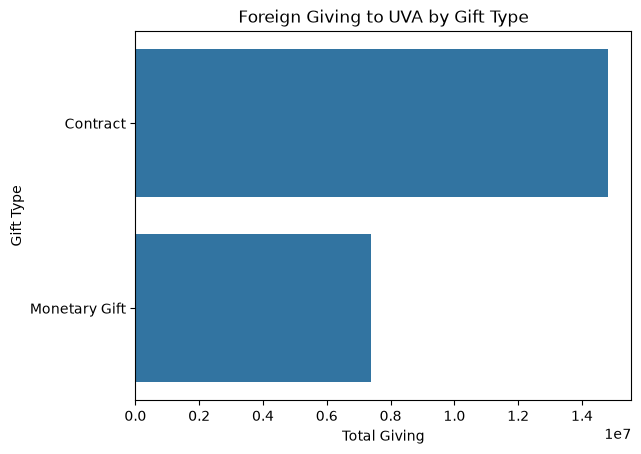

In [32]:
sns.barplot(data = uva_gift_type, x = "sum", y = uva_gift_type.index)
plt.xlabel("Total Giving")
plt.ylabel("Gift Type")
plt.title("Foreign Giving to UVA by Gift Type")
plt.show()

In [34]:
uva_donors = uva.groupby("Giftor Name")["Foreign Gift Amount"].agg(["sum", "count", "mean"]).sort_values("sum", ascending=False)
uva_donors.head(20)

,sum,count,mean
Giftor Name,,,
AstraZeneca,3208048,2,1.604024e+06
Intrnl Centre Diarrheal Disease,1382896,3,4.609653e+05
Haydom Lutheran Hospital d/b/a Hayd,1100553,1,1.100553e+06
Haydom Luther Hospital,1035339,1,1.035339e+06
Harvest Group Holding,1000000,2,5.000000e+05
Lawrence D/ Karin S Howell,1000000,1,1.000000e+06
Lawrence D & Karin S Howell,1000000,1,1.000000e+06
Danisco Sweeteners Oy,990331,4,2.475828e+05
Intnl Centre for Diarrhoeal Disease,919857,2,4.599285e+05


In [70]:
peers = ['University of Michigan - Ann Arbor', 'University of North Carolina - Chapel Hill', 'University of Florida',
         'Virginia Polytechnic Institute & State University', 'College of William & Mary',
         'University of Virginia', 'George Mason University']
peer_df = df[df["Institution Name"].isin(peers)]


In [71]:
peer_summary = (peer_df.groupby("Institution Name")["Foreign Gift Amount"].agg(total_giving="sum",
                                                                               number_of_gifts="count",
                                                                               average_gift="mean",
                                                                               median_gift="median").sort_values
                                                                               ("total_giving", ascending=False))

peer_summary

,total_giving,number_of_gifts,average_gift,median_gift
Institution Name,,,,
University of Michigan - Ann Arbor,287336783,715,4.018696e+05,200000.0
George Mason University,65435604,38,1.721990e+06,507053.5
University of North Carolina - Chapel Hill,41292544,286,1.443795e+05,33548.0
University of Florida,24759139,33,7.502769e+05,483216.0
University of Virginia,22189238,98,2.264208e+05,80535.5
Virginia Polytechnic Institute & State University,11792062,24,4.913359e+05,350000.0
College of William & Mary,3384498,17,1.990881e+05,51600.0


In [75]:
peers_oos = ['University of Michigan - Ann Arbor', 'University of North Carolina - Chapel Hill',
             'University of Florida', 'University of Virginia']
peer_oos_df = df[df["Institution Name"].isin(peers_oos)]

peers_in_state = ['Virginia Polytechnic Institute & State University', 'College of William & Mary',
                  'University of Virginia', 'George Mason University']
peers_in_state_df = df[df["Institution Name"].isin(peers_in_state)]


In [76]:
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'

flows = (
    peer_oos_df.groupby([giftor, recipi])[flow]
    .sum()
    .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

In [77]:
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'

flows = (
    peers_in_state_df.groupby([giftor, recipi])[flow]
    .sum()
    .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

In [ ]:
bermuda = df[df["Country of Giftor"] == "BERMUDA"].copy()
bermuda["Foreign Gift Amount"].sum()

np.int64(899593972)

In [ ]:
bermuda.groupby("Giftor Name")["Foreign Gift Amount"].agg(["sum", "count", "mean"]).sort_values("sum", ascending=False).head(30)

,sum,count,mean
Giftor Name,,,
Anonymous,81396169,15,5.426411e+06
THE ATLANTIC PHILANTHROPIES,35829650,4,8.957412e+06
Tang Family Foundation,4120000,7,5.885714e+05
Axovant Sciences,1769374,35,5.055354e+04
The Atlantic Philanthropies,1700966,2,8.504830e+05
Tang Family,1500000,1,1.500000e+06
Tang Family Foundation,1500000,1,1.500000e+06
Tuhs Insurance Company Ltd,1392300,1,1.392300e+06
Anonymous #14,1002500,2,5.012500e+05


In [69]:
bermuda.groupby("Gift Type")["Foreign Gift Amount"].agg(["sum", "count", "mean", "median"]).sort_values("sum", ascending=False)

,sum,count,mean,median
Gift Type,,,,
Contract,763258472,67,1.139192e+07,50907.0
Monetary Gift,136335500,50,2.726710e+06,749247.5


In [83]:
michigan = df[
    df["Institution Name"] == "University of Michigan - Ann Arbor"
].copy()

michigan_countries = michigan.groupby("Country of Giftor")["Foreign Gift Amount"].agg(total_giving="sum",
                                                                                      number_of_gifts="count",
                                                                                      average_gift="mean",
                                                                                      median_gift="median").sort_values(
                                                                                          "total_giving", ascending=False)


michigan_countries.head(15)

,total_giving,number_of_gifts,average_gift,median_gift
Country of Giftor,,,,
ENGLAND,46023031,85,5.414474e+05,279239.0
JAPAN,32242238,87,3.706004e+05,173306.0
CHINA,27298052,83,3.288922e+05,199818.0
SWITZERLAND,25013810,66,3.789971e+05,263045.0
FRANCE,18369832,34,5.402892e+05,224079.5
HONG KONG,16765692,29,5.781273e+05,400000.0
DENMARK,14148315,23,6.151441e+05,385924.0
KOREA,14023213,64,2.191127e+05,150000.0
GERMANY,12157592,44,2.763089e+05,221840.0


In [86]:
michigan_donors = michigan.groupby(["Country of Giftor", "Giftor Name"])["Foreign Gift Amount"].agg(total_giving="sum",
                                                                                                    number_of_gifts="count",
                                                                                                    average_gift="mean").sort_values(
                                                                                                        "total_giving", ascending=False)

michigan_donors.head(20)

total_giving  \
Country of Giftor Giftor Name                                         
SWITZERLAND       Novartis                                 12503307   
SINGAPORE         Jiong Wu                                 10000000   
DENMARK           Novo Nordisk A/S                          9402351   
FRANCE            Airbus S.A.S.                             9000001   
IRELAND           Frances M. McSparran                      8450000   
CHINA             Frontt Capital Management, Ltd            6127032   
ENGLAND           MeiraGTx Limited                          5920516   
                  Defense Science & Tech Lab (DSTL)         4520843   
SWEDEN            Astra Zeneca AB                           4431702   
FRANCE            Sanofi                                    4345647   
HONG KONG         Ascentage Pharma Group Corp. Ltd          4023642   
CANADA            Li Ka Shing (Canada) Foundation           4000000   
ENGLAND           AstraZeneca PLC                           3634679   
SAUDI ARABIA      King Abdulaziz City for Sci & Tech        3600000   
JAPAN             Toyota Motor Company, LTD                 3286740   
ENGLAND           UK Dept of International Developmen       3222806   
                  Burroughs Wellcome Fund                   3200000   
KOREA             Samsung Group                             3196263   
HONG KONG         William Yat San Chiang                    3125000   
ENGLAND           Chiltern International, Inc.              3066563   

                                                       number_of_gifts  \
Country of Giftor Giftor Name                                            
SWITZERLAND       Novartis                                          32   
SINGAPORE         Jiong Wu                                           1   
DENMARK           Novo Nordisk A/S                                  11   
FRANCE            Airbus S.A.S.                                      2   
IRELAND           Frances M. McSparran                               1   
CHINA             Frontt Capital Management, Ltd                     2   
ENGLAND           MeiraGTx Limited                                   7   
                  Defense Science & Tech Lab (DSTL)                  3   
SWEDEN            Astra Zeneca AB                                   17   
FRANCE            Sanofi                                            10   
HONG KONG         Ascentage Pharma Group Corp. Ltd                   2   
CANADA            Li Ka Shing (Canada) Foundation                    4   
ENGLAND           AstraZeneca PLC                                    8   
SAUDI ARABIA      King Abdulaziz City for Sci & Tech                 1   
JAPAN             Toyota Motor Company, LTD                          2   
ENGLAND           UK Dept of International Developmen                1   
                  Burroughs Wellcome Fund                            1   
KOREA             Samsung Group                                     23   
HONG KONG         William Yat San Chiang                             5   
ENGLAND           Chiltern International, Inc.                       9   

                                                       average_gift  
Country of Giftor Giftor Name                                        
SWITZERLAND       Novartis                             3.907283e+05  
SINGAPORE         Jiong Wu                             1.000000e+07  
DENMARK           Novo Nordisk A/S                     8.547592e+05  
FRANCE            Airbus S.A.S.                        4.500000e+06  
IRELAND           Frances M. McSparran                 8.450000e+06  
CHINA             Frontt Capital Management, Ltd       3.063516e+06  
ENGLAND           MeiraGTx Limited                     8.457880e+05  
                  Defense Science & Tech Lab (DSTL)    1.506948e+06  
SWEDEN            Astra Zeneca AB                      2.606884e+05  
FRANCE            Sanofi                               4.345647e+05  
HONG KONG         Ascen